In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics for Regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Evaluation metrics for Classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [2]:
df= pd.read_csv(r"C:\Users\ssita\pythonclass\student_data (1).csv")
df.head()

,StudentID,Age,Gender,StudyHours,AttendancePercent,PreviousScore,ParentalEducation,InternetAccess,ExtraCurricular,FinalScore,Passed
0,1,18,Male,5,85,60,Graduate,Yes,Yes,72,1
1,2,19,Female,8,92,75,Postgraduate,Yes,Yes,88,1
2,3,17,Male,2,60,45,HighSchool,No,No,40,0
3,4,20,Female,6,78,65,Graduate,Yes,No,70,1
4,5,18,Male,3,55,50,HighSchool,No,Yes,48,0


In [3]:
print("Gender values:", df['Gender'].unique())
print("Parentaleducation values:", df['ParentalEducation'].unique())
print("Internet values:", df['InternetAccess'].unique())
print("Extracurricular values:", df['ExtraCurricular'].unique())

Gender values: ['Male' 'Female']
Parentaleducation values: ['Graduate' 'Postgraduate' 'HighSchool']
Internet values: ['Yes' 'No']
Extracurricular values: ['Yes' 'No']


In [4]:
df_encoded = df.copy()
encoder = LabelEncoder() 

df_encoded["Gender"] = encoder.fit_transform(df_encoded["Gender"]) 
df_encoded["ParentalEducation"] = encoder.fit_transform(df_encoded["ParentalEducation"]) 
df_encoded["InternetAccess"] = encoder.fit_transform(df_encoded["InternetAccess"]) 
df_encoded["ExtraCurricular"] = encoder.fit_transform(df_encoded["ExtraCurricular"])

df_encoded.head()  

,StudentID,Age,Gender,StudyHours,AttendancePercent,PreviousScore,ParentalEducation,InternetAccess,ExtraCurricular,FinalScore,Passed
0,1,18,1,5,85,60,0,1,1,72,1
1,2,19,0,8,92,75,2,1,1,88,1
2,3,17,1,2,60,45,1,0,0,40,0
3,4,20,0,6,78,65,0,1,0,70,1
4,5,18,1,3,55,50,1,0,1,48,0


In [5]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   StudentID          50 non-null     int64
 1   Age                50 non-null     int64
 2   Gender             50 non-null     int64
 3   StudyHours         50 non-null     int64
 4   AttendancePercent  50 non-null     int64
 5   PreviousScore      50 non-null     int64
 6   ParentalEducation  50 non-null     int64
 7   InternetAccess     50 non-null     int64
 8   ExtraCurricular    50 non-null     int64
 9   FinalScore         50 non-null     int64
 10  Passed             50 non-null     int64
dtypes: int64(11)
memory usage: 4.4 KB


In [6]:
#-----------Step 7 Choose the input columns and the output column--------------
feature_columns = ["Age", "Gender", "StudyHours", "ParentalEducation", "InternetAccess", "ExtraCurricular", "AttendancePercent", "PreviousScore"]

x= df_encoded[feature_columns]
y_score = df_encoded["FinalScore"]
y_passed = df_encoded["Passed"]

print("Shape of x:", x.shape)
print("Shape of y_score:", y_score.shape)
print("Shape of y_passed:", y_passed.shape)

Shape of x: (50, 8)
Shape of y_score: (50,)
Shape of y_passed: (50,)


In [10]:
#------------Step 8 Split the data into training and testing sets--------------------

x_train, x_test, y_score_train, y_score_test = train_test_split(x, y_score, test_size=0.2, random_state=42)
x_train, x_test, y_passed_train, y_passed_test = train_test_split(x, y_passed, test_size=0.2, random_state=42)

print("Training rows:", x_train.shape[0]) 
print("Testing rows:", x_test.shape[0])

Training rows: 40
Testing rows: 10


In [11]:
#------------part A Regression Models: Linear Regression-------------
lin_reg_model = LinearRegression()
lin_reg_model.fit(x_train, y_score_train) 
lin_reg_pred = lin_reg_model.predict(x_test) 

lin_reg_r2 = r2_score(y_score_test, lin_reg_pred) 
lin_reg_mae = mean_absolute_error(y_score_test, lin_reg_pred) 
lin_reg_mse = mean_squared_error(y_score_test, lin_reg_pred) 
lin_reg_rmse = np.sqrt(lin_reg_mse) 

print("Linear Regression Results") 
print("R2 Squared:",round(lin_reg_r2, 3))
print("Mean Absolute Error:", round(lin_reg_mae, 3)) 
print("Mean Squared Error:", round(lin_reg_mse, 3))
print("Root Mean Squared Error:", round(lin_reg_rmse, 3)) 


Linear Regression Results
R2 Squared: 0.991
Mean Absolute Error: 1.513
Mean Squared Error: 3.933
Root Mean Squared Error: 1.983


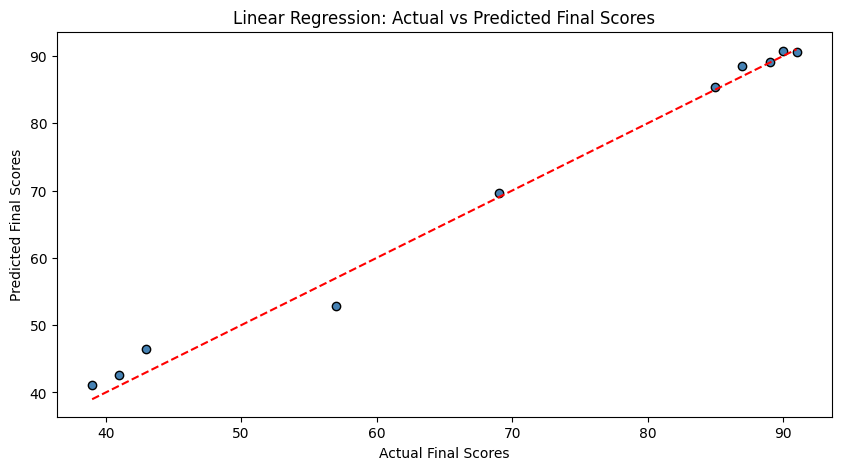

Linear Regression Coefficients:(how much each column affects the score):
InternetAccess       4.280155
ExtraCurricular      1.018205
PreviousScore        0.817554
Gender               0.393420
AttendancePercent    0.348606
StudyHours           0.303589
Age                  0.228900
ParentalEducation   -0.777229
dtype: float64


In [14]:
#_-------------plot the values of linear regression model---------------\\
plt.figure(figsize=(10,5)) 
plt.scatter(y_score_test, lin_reg_pred, color="steelblue", edgecolor="black")
plt.plot([y_score_test.min(), y_score_test.max()], [y_score_test.min(), y_score_test.max()], color="red", linestyle="--") 
plt.xlabel("Actual Final Scores") 
plt.ylabel("Predicted Final Scores") 
plt.title("Linear Regression: Actual vs Predicted Final Scores") 
plt.show() 

coef_table = pd.Series(lin_reg_model.coef_, index=feature_columns) 
print("Linear Regression Coefficients:(how much each column affects the score):") 
print(coef_table.sort_values(ascending=False))

In [ ]:
#---------------Regression Model 2 : Polynomial Regression----------------